In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import duckdb

In [2]:
con = duckdb.connect(r'C:\Users\marzieh\Documents\GitHub\Tennis-project\data\tennis.duckdb', read_only=True)
con.execute("SHOW TABLES").df()

,name
0,_build_info
1,_import_audit
2,_schema_audit
3,_source_files
4,game_point_by_point
5,match_away_score
6,match_away_team
7,match_event
8,match_home_score
9,match_home_team


In [3]:
query = """
    SELECT match_id, initial_fractional_value, winnig
    FROM odds
    WHERE market_name = 'full_time'
    AND initial_fractional_value IS NOT NULL
    AND winnig IS NOT NULL
"""
df = con.execute(query).df()
df

,match_id,initial_fractional_value,winnig
0,11974066,14/1,False
1,11974066,1/33,True
2,11998448,11/10,True
3,11998448,8/11,False
4,11998450,11/10,False
...,...,...,...
41659,12213412,11/10,True
41660,12213460,1/5,True
41661,12213460,10/3,False
41662,12213486,1/4,True


In [4]:
def fractional_to_decimal(x):
    if pd.isna(x):
        return np.nan
    try:
        a, b = x.split("/")
        a = float(a)
        b = float(b)
        return 1 + (a / b)
    except:
        return np.nan

def fractional_to_probability(x):
    if pd.isna(x):
        return np.nan
    try:
        a, b = x.split("/")
        a = float(a)
        b = float(b)
        return b / (a + b)
    except:
        return np.nan

In [5]:
df["initial_decimal_odds"] = df["initial_fractional_value"].apply(fractional_to_decimal)
df["initial_implied_probability"] = df["initial_fractional_value"].apply(fractional_to_probability)
clean_df = df[df["initial_decimal_odds"].notna()].copy()
clean_df

,match_id,initial_fractional_value,winnig,initial_decimal_odds,initial_implied_probability
0,11974066,14/1,False,15.000000,0.066667
1,11974066,1/33,True,1.030303,0.970588
2,11998448,11/10,True,2.100000,0.476190
3,11998448,8/11,False,1.727273,0.578947
4,11998450,11/10,False,2.100000,0.476190
...,...,...,...,...,...
41659,12213412,11/10,True,2.100000,0.476190
41660,12213460,1/5,True,1.200000,0.833333
41661,12213460,10/3,False,4.333333,0.230769
41662,12213486,1/4,True,1.250000,0.800000


In [6]:
summary = df.groupby("winnig")[["initial_implied_probability", "initial_decimal_odds"]].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"
])

summary

initial_implied_probability                                          \
                             count      mean    median       std       min   
winnig                                                                       
False                        20845  0.424053  0.400000  0.207900  0.009901   
True                         20687  0.632517  0.636364  0.212518  0.058824   

            initial_decimal_odds                                            
        max                count      mean    median       std  min    max  
winnig                                                                      
False   1.0                20845  3.423707  2.500000  3.525640  1.0  101.0  
True    1.0                20687  1.882616  1.571429  1.090602  1.0   17.0

# Plot

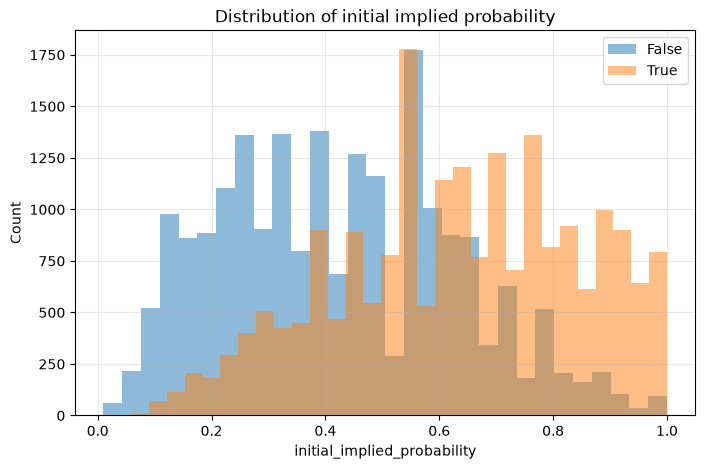

In [28]:
plot_df = df.dropna(subset=["initial_implied_probability", "winnig"]).copy()

true_values = plot_df.loc[plot_df["winnig"] == True, "initial_implied_probability"]
false_values = plot_df.loc[plot_df["winnig"] == False, "initial_implied_probability"]

plt.figure(figsize=(8, 5))
plt.hist(false_values, bins=30, alpha=0.5, label="False")
plt.hist(true_values, bins=30, alpha=0.5, label="True")
plt.xlabel("initial_implied_probability")
plt.ylabel("Count")
plt.title("Distribution of initial implied probability")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

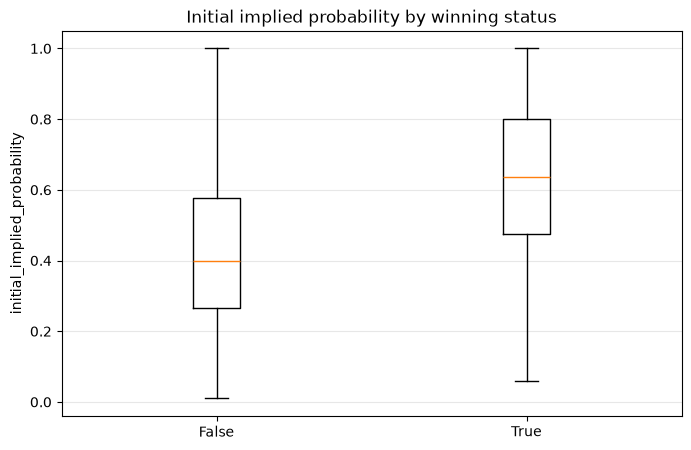

In [27]:
plot_df = clean_df.dropna(subset=["initial_implied_probability", "winnig"]).copy()

true_values = plot_df.loc[plot_df["winnig"] == True, "initial_implied_probability"]
false_values = plot_df.loc[plot_df["winnig"] == False, "initial_implied_probability"]

plt.figure(figsize=(8, 5))
plt.boxplot([false_values, true_values], tick_labels=["False", "True"])
plt.ylabel("initial_implied_probability")
plt.title("Initial implied probability by winning status")
plt.grid(axis="y", alpha=0.3)
plt.show()
